In [49]:
import numpy as np
import scipy
from scipy import special
import matplotlib.pyplot as plt
from numba import njit
from functools import lru_cache

Usefull constants

In [50]:
hbarc=197.32698 #MeV*fm
mp=939.56563 #MeV
mn=938.27203 #MeV
mu=(mp*mn)/(mp+mn)/hbarc #fm^-1
mpi=138.04/hbarc #fm^-1
Fpi=184.80/hbarc #fm^-1
gA=1.29
htm=hbarc/2./mu #MeV*fm^2
m_d=1875.612945/hbarc #fm^-1
mu_p=2.793 #nuclear magneton
mu_n=-1.913 #nuclear magneton

The following code compute the Clebch Gordan coefficients needed for constructing the wave functions

In [51]:
from sympy.physics.quantum.cg import CG

@lru_cache(None)
def clebsch_gordan(j1, m1, j2, m2, J, M):
     return float(CG(j1, m1, j2, m2, J, M).doit())

cg_cache = {}
cg_cache[(0, 0, 1,  1, 1,  1)] = clebsch_gordan(0, 0, 1,  1, 1, 1)
cg_cache[(0, 0, 1,  0, 1,  0)] = clebsch_gordan(0, 0, 1,  0, 1, 0)
cg_cache[(0, 0, 1, -1, 1, -1)] = clebsch_gordan(0, 0, 1, -1, 1, -1)
for i in range(-2, 3):
     for j in range(-1, 2):
         if abs(i + j) < 3:
             cg_cache[(2, i * 1.0, 1, j, 1, i + j)] = clebsch_gordan(2,i, 1, j, 1, i + j)
for i in range(-1, 2):
     for j in range(-1, 2):
         cg_cache[(0.5, i/2, 0.5, j/2, 1, (i+j)/2)] = clebsch_gordan(0.5, i/2, 0.5, j/2, 1, (i+j)/2)
         cg_cache[(0.5, i/2, 0.5, j/2, 0, (i+j)/2)] = clebsch_gordan(0.5, i/2, 0.5, j/2, 0, (i+j)/2)

# cg_cache[(j1,m1,j2,m2,J,M)] = <j1,m1,j2,m2|J,M>

In [52]:
#Spherical harmonic functions for constructing the deuteron wave function
@njit
def Y2(m, theta, phi):
    if abs(m) == 2:
        return np.sqrt(15 / (32 * np.pi)) * np.sin(theta)**2 * np.exp(1j * m * phi)
    elif abs(m) == 1:
        return np.sqrt(15 / (8 * np.pi)) * np.sin(theta) * np.cos(theta) * np.exp(1j * m * phi)
    elif m == 0:
        return np.sqrt(5 / (16 * np.pi)) * (3 * np.cos(theta)**2 - 1) * np.exp(1j * m * phi)
    else:
        return 0.0

@njit
def Y0():
    return 0.5 / np.sqrt(np.pi)

def f_l(l, gamma, x):  # x = gamma * r
    norm = np.sqrt(1. / ((l + 1.) * (l + 2.)) * gamma**3)
    return norm * special.eval_genlaguerre(l, 2.0, x)

In [53]:
#Read the file that contains the deuteron coefficeints
# Now read everything back
with open("deuteron_data.txt", "r") as f:
    lines = f.readlines()

# Parse the contents
gamma = float(lines[0].split(":")[1].strip())
num_of_laguerre = int(lines[1].split(":")[1].strip())
smallest_eigenvalue = float(lines[2].split(":")[1].strip())
d_coeff = np.array(list(map(float, lines[3].split(":")[1].strip().split())))

# Print to confirm
print("Read from file:")
print(f"gamma = {gamma}")
print(f"num_of_laguerre = {num_of_laguerre}")
print(f"smallest_eigenvalue = {smallest_eigenvalue}")
print(f"deuteron wave function (length {len(d_coeff)})")

Read from file:
gamma = 4.0
num_of_laguerre = 40
smallest_eigenvalue = -2.224546437803458
deuteron wave function (length 80)


In [54]:
#Set the values of the spin and isospin corresponding to
#the wave function matrix elements
sz=np.zeros([4,4])
sz[0,0]= 1; sz[0,1]= 1
sz[1,0]=-1; sz[1,1]= 1
sz[2,0]= 1; sz[2,1]=-1
sz[3,0]=-1; sz[3,1]=-1

tz=np.zeros([2,2])
tz[0,0]=-1; tz[0,1]= 1
tz[1,0]= 1; tz[1,1]=-1

In [55]:
# Pauli matrices and 4x4 two-nucleon spin operators
# Spin basis ordering: particle 2 slow, particle 1 fast (matches sz array)
# sigma[particle, component] gives the (4,4) matrix for sigma_x/y/z on that nucleon
sx_op  = np.array([[0,  1 ], [1,  0 ]], dtype=complex)
sy_op  = np.array([[0, -1j], [1j, 0 ]], dtype=complex)
sz_op  = np.array([[1,  0 ], [0, -1 ]], dtype=complex)
I2     = np.eye(2, dtype=complex)

sigma = np.array([
    [np.kron(I2, sx_op), np.kron(I2, sy_op), np.kron(I2, sz_op)],  # particle 0
    [np.kron(sx_op, I2), np.kron(sy_op, I2), np.kron(sz_op, I2)],  # particle 1
])
# Usage: sigma[particle, 0/1/2] @ psi  applies sigma_x/y/z to that particle

In [56]:
#Construct the wave function as a matrix
#sp\iso    (-1,1) (1,-1)    
#( 1 ,1)   psi_00 psi_01
#(-1, 1)   psi_10 psi_11
#( 1,-1)   psi_20 psi_21
#(-1,-1)   psi_30 psi_31
def compute_psi(rr, Jz):
    r = rr[0:3] - rr[3:6]  # relative coordinate; CM shift cancels in difference
    r2 = np.sqrt(np.sum(r**2))

    # Radial wavefunction: pull exp out of the loop (same for every l1)
    exp_r = np.exp(-0.5 * gamma * r2)
    f0 = f2 = 0.0
    for l1 in range(num_of_laguerre):
        val = exp_r * f_l(l1, gamma, gamma * r2)
        f0 += d_coeff[l1] * val
        f2 += d_coeff[num_of_laguerre + l1] * val

    theta = 0.0 if r2 == 0 else np.arccos(r[2] / r2)
    phi = np.arctan2(r[1], r[0])
    if phi < 0:
        phi += 2 * np.pi

    # Precompute isospin CG (independent of spin index i)
    iso_cg = [cg_cache[(0.5, tz[j, 0]/2, 0.5, tz[j, 1]/2, 0, 0)] for j in range(2)]

    psi = np.zeros((4, 2), dtype=np.complex128)
    for i in range(4):
        sz_total = sz[i, 0] + sz[i, 1]
        M = Jz - sz_total / 2
        spin_cg = cg_cache[(0.5, sz[i, 0]/2, 0.5, sz[i, 1]/2, 1, sz_total/2)]
        psi0 = f0 * Y0()  * cg_cache.get((0, M, 1, sz_total/2, 1, Jz), 0.0) * spin_cg
        psi2 = f2 * Y2(M, theta, phi) * cg_cache.get((2, M, 1, sz_total/2, 1, Jz), 0.0) * spin_cg
        for j in range(2):
            psi[i, j] = (psi0 + psi2) * iso_cg[j]

    return psi

In [57]:
def psi_norm(psi):
    """Compute squared norm of psi as a probability weight."""
    return np.sum(np.abs(psi)**2)

def metropolis_step(rr, Jz, step_size):
    """Perform one Metropolis-Hastings step."""
    psi_old = compute_psi(rr, Jz)
    prob_old = psi_norm(psi_old)

    rr_new = rr +step_size*np.random.uniform(low=-1.0, high=1.0, size=6)
    psi_new = compute_psi(rr_new, Jz)
    prob_new = psi_norm(psi_new)

    acceptance_ratio = prob_new / prob_old if prob_old > 0 else 1.0
    if np.random.rand() < min(1.0, acceptance_ratio):
        acc=1
        return rr_new, psi_new, acc  # accept
    else:
        acc=0
        return rr, psi_old, acc      # reject

def run_markov_chain(
    init_rr,
    Jz,
    steps=10000,
    step_size=0.1,
    thermalization=1000,
    nt=10
):
    """
    Run a Markov chain Monte Carlo to sample from |psi(rr, Jz)|^2.
    
    Parameters:
        init_rr       : initial 6D configuration (numpy array)
        Jz            : total spin projection
        steps         : total number of sampling steps *after* thermalization
        step_size     : width of random proposal
        thermalization: number of initial steps to discard
        nt            : save one sample every `nt` steps
    
    Returns:
        samples : array of sampled configurations (shape: [n_saved, 6])
    """
    rr = init_rr.copy()
    
    # Step 1: Thermalization (burn-in)
    for _ in range(thermalization):
        rr, _ , _  = metropolis_step(rr, Jz, step_size)
    
    # Step 2: Sampling with thinning
    samples = []
    wf = []
    tot_acc=0.
    for i in range(steps * nt):
        rr, psi, acc = metropolis_step(rr, Jz, step_size)
        tot_acc=tot_acc+acc
        if i % nt == 0:
            samples.append(rr.copy())
            wf.append(psi.copy())
    return np.array(samples),np.array(wf),tot_acc


In [58]:
init_rr = np.random.uniform(low=-1.0, high=1.0, size=6)
Jz = 1           #z-component of the total angular momentum of the deuteron
nsteps=10000    #number of saved samples
nt=10            #number of steps for uncorrelation
step_size=1.2    #size of the step for the new coordinates
thermalization=1000 #number of thermalization step

samples,wf, tot_acc = run_markov_chain(
    init_rr,
    Jz,
    steps=nsteps,         # Keep 5000 samples
    step_size=step_size,
    thermalization=thermalization,
    nt=nt               # Save every 10 steps → 50,000 total steps
)
print(tot_acc/(nsteps*nt))
print("Collected", len(samples), "uncorrelated samples.")


0.62082
Collected 10000 uncorrelated samples.


In [59]:
import numpy as np

block_size = 100
nsteps = samples.shape[0]
nblocks = nsteps // block_size

print(wf.shape)

block_r2 = []
block_r4 = []

for b in range(nblocks):
    s   = samples[b*block_size:(b+1)*block_size]   # (block_size, 6)
    rel = s[:, :3] - s[:, 3:]                       # r1 - r2, shape (block_size, 3)
    # 0.5*(|r1'|² + |r2'|²) in CM frame = |r1-r2|²/4
    rms_block = np.mean(np.sum(rel**2, axis=1)) / 4
    block_r2.append(rms_block)
    block_r4.append(rms_block**2)

block_r2 = np.array(block_r2)
block_r4 = np.array(block_r4)

mean_rms      = np.mean(block_r2)
mean_rms2     = np.mean(block_r4)
variance_rms  = np.sqrt((mean_rms2 - mean_rms**2) / nblocks)

print("Mean RMS over blocks:   ", np.sqrt(mean_rms))
print("Variance of RMS values: ", (1.0 / np.sqrt(mean_rms)) / 2 * variance_rms)

(10000, 4, 2)
Mean RMS over blocks:    1.8887508920177312
Variance of RMS values:  0.03432700474444112


Here starts the part where we compute the matrix elements with the current

In [87]:
#Proton and neutron form factors
def Form_factors(w,q):
    Q2=q**2-w**2
    Q2GeV=Q2*hbarc**2/1000**2 #GeV^2
    tau=Q2/4./(mp/hbarc)**2
    G_Ep=(1.-0.24*tau)/(1+10.97*tau+12.82*tau**2+21.97*tau**3) #Proton electric form factor
    G_En=1.70*tau/(1+3.3*tau)*(1+Q2GeV/0.71)**(-2)             #Neutron electric form factor
    G_Mp=mu_p*(1.+0.12*tau)/(1+10.97*tau+18.86*tau**2+6.55*tau**3) #Proton Magnetic form factor
    G_Mn=mu_n*(1.+2.33*tau)/(1+14.72*tau+24.20*tau**2+84.1*tau**3) #Neutron Magnetic form factor
    return G_Ep,G_En,G_Mp,G_Mn

def EDM_form_factors(w,q):
    Q2=q**2-w**2
    Q2GeV=Q2*hbarc**2/1000**2 #GeV^2
    d0=0.54
    d1=-1.73
    Lambda=1 #GeV
    D0=d0/(1+Q2GeV/Lambda**2)**2
    D1=d1/(1+Q2GeV/Lambda**2)**2
    return D0, D1


In [93]:
def current(hatq, q, w, r, psi, Jz):
    h = 0.001
    G_Ep, G_En, G_Mp, G_Mn = Form_factors(w, q)
    G_Es  = G_Ep + G_En
    G_Ev  = G_Ep - G_En
    G_Mss = G_Mp + G_Mn   # isoscalar magnetic
    G_Mvv = G_Mp - G_Mn   # isovector magnetic
    D0, D1 = EDM_form_factors(w, q)
    
    norm   = np.sum(np.abs(psi)**2)
    psidag = psi.conj()

    rho     = np.zeros(q.size, dtype=np.complex128)
    rho_edm = np.zeros(q.size, dtype=np.complex128)
    J       = np.zeros((3, q.size), dtype=np.complex128)
    J_edm   = np.zeros((3, q.size), dtype=np.complex128)
    #print(psi)
    for i in range(2):
        tz_psi = psi * tz[:, i]
        eiqr   = np.exp(1j * q * np.dot(hatq, r[i]))
        sum_tz = np.sum(psidag * tz_psi)

        rho += eiqr * 0.5 * (G_Es * norm + G_Ev * sum_tz)

        # σ·q̂ for particle i: explicit sum over xyz components
        hatq_sigma_i = hatq[0]*sigma[i,0] + hatq[1]*sigma[i,1] + hatq[2]*sigma[i,2]  # shape (4,4)

        sigqedm        = hatq_sigma_i @ psi
        tz_sigqedm     = sigqedm * tz[:,i]
        sum_sigqedm    = np.sum(psidag * sigqedm)
        sum_tz_sigqedm = np.sum(psidag * tz_sigqedm)
        
        rho_edm += 0.5j * q * eiqr * (D0 * sum_sigqedm + D1 * sum_tz_sigqedm)
        
        # (hatq x sigma^(i))_j — precomputed for all j outside the j loop
        hatq_x_sigma = np.array([
            hatq[1]*sigma[i,2] - hatq[2]*sigma[i,1],
            hatq[2]*sigma[i,0] - hatq[0]*sigma[i,2],
            hatq[0]*sigma[i,1] - hatq[1]*sigma[i,0],
        ])  # shape (3, 4, 4)
          
        for j in range(3):
            #print(i,j,sigma[i,j] @ psi)
            # Convection current via finite-difference gradient
            rp = r.copy(); rp[i, j] += h
            rm = r.copy(); rm[i, j] -= h
            dpsi    = (compute_psi(rp.flatten(), Jz)
                     - compute_psi(rm.flatten(), Jz)) / (2 * h)
            tz_dpsi = dpsi * tz[:, i]

            sum_dpsi    = np.sum(psidag * dpsi)
            sum_tz_dpsi = np.sum(psidag * tz_dpsi)

            J[j] += eiqr * 0.5 * (q * hatq[j] * (G_Es * norm     + G_Ev * sum_tz)
                                   - 2j         * (G_Es * sum_dpsi + G_Ev * sum_tz_dpsi))

            # Spin (magnetization) current: i*q * (hatq x sigma^(i))_j
            sigma_j_psi  = hatq_x_sigma[j] @ psi
            tz_sigma_psi = sigma_j_psi * tz[:, i]
            sum_sigma    = np.sum(psidag * sigma_j_psi)
            sum_tz_sigma = np.sum(psidag * tz_sigma_psi)
            #print(j,sum_sigma)
            
            J[j] += eiqr * 0.5j  * q * (G_Mss * sum_sigma + G_Mvv * sum_tz_sigma)

            #EDM current
            sigedm     = sigma[i,j] @ psi
            tz_sigedm  = sigedm * tz[:,i]
            sum_sigedm = np.sum(psidag * sigedm)
            sum_tz_sigedm = np.sum(psidag * tz_sigedm)
            J_edm[j] += eiqr * 0.5j * w * (D0 * sum_sigedm + D1 * sum_tz_sigedm)
    
    # Build right-handed frame {e0, e1, e2} with e2 along hatq.
    e2 = hatq
    e1 = np.cross(np.array([0., 0., 1.]), e2)
    if np.linalg.norm(e1) < 1e-10:          # hatq parallel to z: use y as reference
        e1 = np.cross(np.array([0., 1., 0.]), e2)
    e1  = e1 / np.linalg.norm(e1)
    e0  = np.cross(e1, e2)
    rot = np.array([e0, e1, e2])             # (3,3): rows are basis vectors

    J_clas = rot @ J/(2*mp/hbarc)                          # (3, q.size): J in the q-aligned frame
    J_edm  = rot @ J_edm
 
    return rho / norm, rho_edm / norm, J_clas / norm, J_edm / norm

In [94]:
#setting the kinematics
hatqx=np.zeros(3) #Momentum direction along x
hatqx[0]=1.
hatqx[1]=0.
hatqx[2]=0.
hatqz=np.zeros(3) #Momentum direction along z
hatqz[0]=0.
hatqz[1]=0.
hatqz[2]=1.
q = np.arange(0.0, 6.5, 0.1) #magnitude of the three momentum transfered in fm
w=np.sqrt(q**2+m_d**2)-m_d
Q2=q**2-w**2

In [95]:
block_size = 100
nblocks = nsteps // block_size
print("Number of blocks:", nblocks)

block_rho_real    = []
block_rho_imag    = []
block_rho2_real   = []
block_rho2_imag   = []
block_rhoedm_real  = []
block_rhoedm_imag  = []
block_rhoedm2_real = []
block_rhoedm2_imag = []
block_J_real      = []
block_J_imag      = []
block_J2_real     = []
block_J2_imag     = []
block_Jedm_real   = []
block_Jedm_imag   = []
block_Jedm2_real  = []
block_Jedm2_imag  = []

rr = np.zeros([2, 3])

for b in range(nblocks):
    mean_rho_block    = np.zeros(2 * q.size, dtype=np.complex128)
    mean_rhoedm_block = np.zeros(    q.size, dtype=np.complex128)
    mean_J_block      = np.zeros((3, q.size), dtype=np.complex128)
    mean_Jedm_block   = np.zeros((3, q.size), dtype=np.complex128)

    for i in range(b * block_size, (b + 1) * block_size):
        rr[0] = samples[i, 0:3]
        rr[1] = samples[i, 3:6]
        R_cm  = 0.5 * (rr[0] + rr[1])
        rr   -= R_cm

        rho_z, rho_edm_z, _, _     = current(hatqz, q, w, rr, wf[i], Jz)
        rho_x, rho_edm_x, J_x, J_edm_x     = current(hatqx, q, w, rr, wf[i], Jz)

        mean_rho_block    += np.hstack((rho_z,     rho_x))
        mean_rhoedm_block += rho_edm_z
        mean_J_block      += J_x
        mean_Jedm_block   += J_edm_x

    rho_block    = mean_rho_block    / block_size
    rhoedm_block = mean_rhoedm_block / block_size
    J_block      = mean_J_block      / block_size
    Jedm_block   = mean_Jedm_block   / block_size

    block_rho_real.append(rho_block.real)
    block_rho_imag.append(rho_block.imag)
    block_rho2_real.append(rho_block.real**2)
    block_rho2_imag.append(rho_block.imag**2)

    block_rhoedm_real.append(rhoedm_block.real)
    block_rhoedm_imag.append(rhoedm_block.imag)
    block_rhoedm2_real.append(rhoedm_block.real**2)
    block_rhoedm2_imag.append(rhoedm_block.imag**2)

    block_J_real.append(J_block.real)
    block_J_imag.append(J_block.imag)
    block_J2_real.append(J_block.real**2)
    block_J2_imag.append(J_block.imag**2)

    block_Jedm_real.append(Jedm_block.real)
    block_Jedm_imag.append(Jedm_block.imag)
    block_Jedm2_real.append(Jedm_block.real**2)
    block_Jedm2_imag.append(Jedm_block.imag**2)

block_rho_real    = np.array(block_rho_real)
block_rho_imag    = np.array(block_rho_imag)
block_rho2_real   = np.array(block_rho2_real)
block_rho2_imag   = np.array(block_rho2_imag)
block_rhoedm_real  = np.array(block_rhoedm_real)
block_rhoedm_imag  = np.array(block_rhoedm_imag)
block_rhoedm2_real = np.array(block_rhoedm2_real)
block_rhoedm2_imag = np.array(block_rhoedm2_imag)
block_J_real      = np.array(block_J_real)
block_J_imag      = np.array(block_J_imag)
block_J2_real     = np.array(block_J2_real)
block_J2_imag     = np.array(block_J2_imag)
block_Jedm_real   = np.array(block_Jedm_real)
block_Jedm_imag   = np.array(block_Jedm_imag)
block_Jedm2_real  = np.array(block_Jedm2_real)
block_Jedm2_imag  = np.array(block_Jedm2_imag)

print("Block rho shape:", block_rho_real.shape)
print("Block J shape:  ", block_J_real.shape)

Nq = 2 * q.size
mean_rho_real     = np.mean(block_rho_real,  axis=0)
mean_rho_imag     = np.mean(block_rho_imag,  axis=0)
variance_rho_real = np.sqrt((np.mean(block_rho2_real, axis=0) - mean_rho_real**2) / nblocks)
variance_rho_imag = np.sqrt((np.mean(block_rho2_imag, axis=0) - mean_rho_imag**2) / nblocks)

mean_rhoedm_real     = np.mean(block_rhoedm_real,  axis=0)
mean_rhoedm_imag     = np.mean(block_rhoedm_imag,  axis=0)
variance_rhoedm_real = np.sqrt((np.mean(block_rhoedm2_real, axis=0) - mean_rhoedm_real**2) / nblocks)
variance_rhoedm_imag = np.sqrt((np.mean(block_rhoedm2_imag, axis=0) - mean_rhoedm_imag**2) / nblocks)

mean_J_real     = np.mean(block_J_real,  axis=0)
mean_J_imag     = np.mean(block_J_imag,  axis=0)
variance_J_real = np.sqrt((np.mean(block_J2_real, axis=0) - mean_J_real**2) / nblocks)
variance_J_imag = np.sqrt((np.mean(block_J2_imag, axis=0) - mean_J_imag**2) / nblocks)

mean_Jedm_real     = np.mean(block_Jedm_real,  axis=0)
mean_Jedm_imag     = np.mean(block_Jedm_imag,  axis=0)
variance_Jedm_real = np.sqrt((np.mean(block_Jedm2_real, axis=0) - mean_Jedm_real**2) / nblocks)
variance_Jedm_imag = np.sqrt((np.mean(block_Jedm2_imag, axis=0) - mean_Jedm_imag**2) / nblocks)


Number of blocks: 100
Block rho shape: (100, 130)
Block J shape:   (100, 3, 65)


In [97]:
# Constants
prefactor_c0 = 1.0 / np.sqrt(12 * np.pi)
prefactor_c2 = np.sqrt(2.0 / (3 * np.pi))
prefactor_c1 = 1j / np.sqrt(2 * np.pi)

# Initialize arrays
C_0 = np.zeros(q.size)
C_2 = np.zeros(q.size)
C_1 = np.zeros(q.size, dtype=complex)
C_0_sq = np.zeros(q.size)
C_2_sq = np.zeros(q.size)
C_1_sq = np.zeros(q.size)
C_0_err = np.zeros(q.size)
C_2_err = np.zeros(q.size)
C_1_err = np.zeros(q.size)
C_0_sq_err = np.zeros(q.size)
C_2_sq_err = np.zeros(q.size)
C_1_sq_err = np.zeros(q.size)

# Compute C0, C2, C1 and propagate errors
for i in range(q.size):
    rho_z_real   = mean_rho_real[i]
    rho_x_real   = mean_rho_real[i + q.size]
    rho_edm_imag = mean_rhoedm_imag[i]

    sigma_z      = variance_rho_real[i]
    sigma_x      = variance_rho_real[i + q.size]
    sigma_edm    = variance_rhoedm_imag[i]

    # Reduced matrix elements
    C_0[i] = prefactor_c0 * (rho_z_real + 2 * rho_x_real)
    C_2[i] = prefactor_c2 * (-rho_z_real + rho_x_real)
    C_1[i] = prefactor_c1 * rho_edm_imag

    # Errors
    C_0_err[i] = prefactor_c0 * np.sqrt(sigma_z**2 + (2 * sigma_x)**2)
    C_2_err[i] = prefactor_c2 * np.sqrt(sigma_z**2 + sigma_x**2)
    C_1_err[i] = abs(prefactor_c1) * sigma_edm

    # Squares
    C_0_sq[i] = C_0[i]**2
    C_2_sq[i] = C_2[i]**2
    C_1_sq[i] = abs(C_1[i])**2

    # Errors on squares: Δ(|f|²) = 2|f| Δ|f|
    C_0_sq_err[i] = 2 * abs(C_0[i]) * C_0_err[i]
    C_2_sq_err[i] = 2 * abs(C_2[i]) * C_2_err[i]
    C_1_sq_err[i] = 2 * abs(C_1[i]) * C_1_err[i]


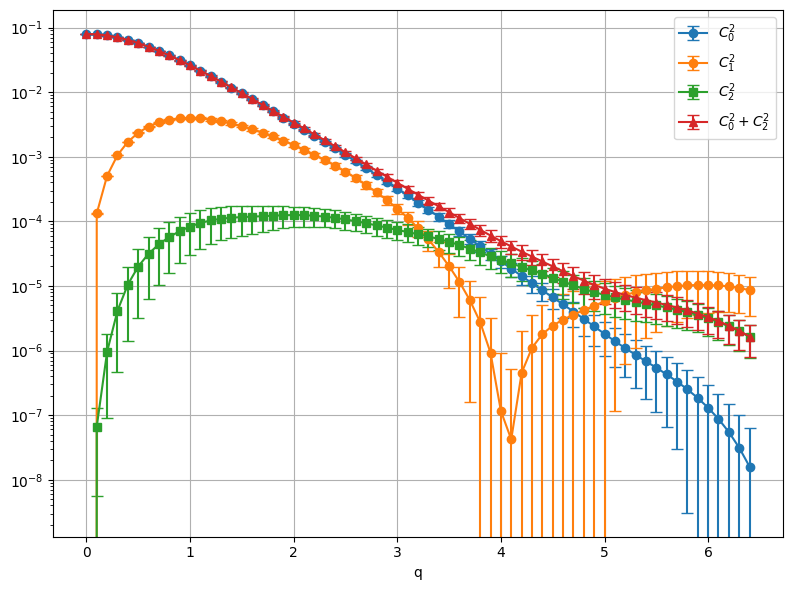

In [98]:
import matplotlib.pyplot as plt

# Sum of squares and propagate errors assuming independent errors
C_sum_sq = C_0_sq + C_2_sq 
C_sum_sq_err = np.sqrt(C_0_sq_err**2 + C_2_sq_err**2)

plt.figure(figsize=(8,6))

# Plot C0^2
plt.errorbar(q, 1/3*C_0_sq, yerr=1/3*C_0_sq_err, fmt='o-', label=r'$C_0^2$', capsize=4)

# Plot C1^2
plt.errorbar(q, 1/3*C_1_sq, yerr=1/3*C_1_sq_err, fmt='o-', label=r'$C_1^2$', capsize=4)

# Plot C2^2
plt.errorbar(q, 1/3*C_2_sq, yerr=1/3*C_2_sq_err, fmt='s-', label=r'$C_2^2$', capsize=4)

# Plot sum C0^2 + C2^2
plt.errorbar(q, 1/3*C_sum_sq, yerr=1/3*C_sum_sq_err, fmt='^-', label=r'$C_0^2 + C_2^2$', capsize=4)

plt.xlabel('q')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.yscale('log')
plt.show()

q[0]: M_1 = 0.000000e+00 + 0.000000e+00i  |  |M_1|^2 = 0.000000e+00 +/- 0.00e+00
q[1]: M_1 = 3.875743e-05 + -4.618228e-03i  |  |M_1|^2 = 2.132953e-05 +/- 5.71e-08
q[2]: M_1 = 7.491263e-05 + -9.040662e-03i  |  |M_1|^2 = 8.173918e-05 +/- 2.34e-07
q[3]: M_1 = 1.058551e-04 + -1.309772e-02i  |  |M_1|^2 = 1.715616e-04 +/- 8.96e-07
q[4]: M_1 = 1.290558e-04 + -1.666599e-02i  |  |M_1|^2 = 2.777718e-04 +/- 2.49e-06
q[5]: M_1 = 1.423058e-04 + -1.967749e-02i  |  |M_1|^2 = 3.872239e-04 +/- 5.12e-06
q[6]: M_1 = 1.440765e-04 + -2.211723e-02i  |  |M_1|^2 = 4.891927e-04 +/- 8.53e-06
q[7]: M_1 = 1.339050e-04 + -2.401111e-02i  |  |M_1|^2 = 5.765515e-04 +/- 1.23e-05
q[8]: M_1 = 1.126670e-04 + -2.540892e-02i  |  |M_1|^2 = 6.456260e-04 +/- 1.58e-05
q[9]: M_1 = 8.261763e-05 + -2.636774e-02i  |  |M_1|^2 = 6.952644e-04 +/- 1.88e-05
q[10]: M_1 = 4.713891e-05 + -2.694013e-02i  |  |M_1|^2 = 7.257727e-04 +/- 2.12e-05
q[11]: M_1 = 1.022244e-05 + -2.716919e-02i  |  |M_1|^2 = 7.381652e-04 +/- 2.31e-05
q[12]: M_1 = -2

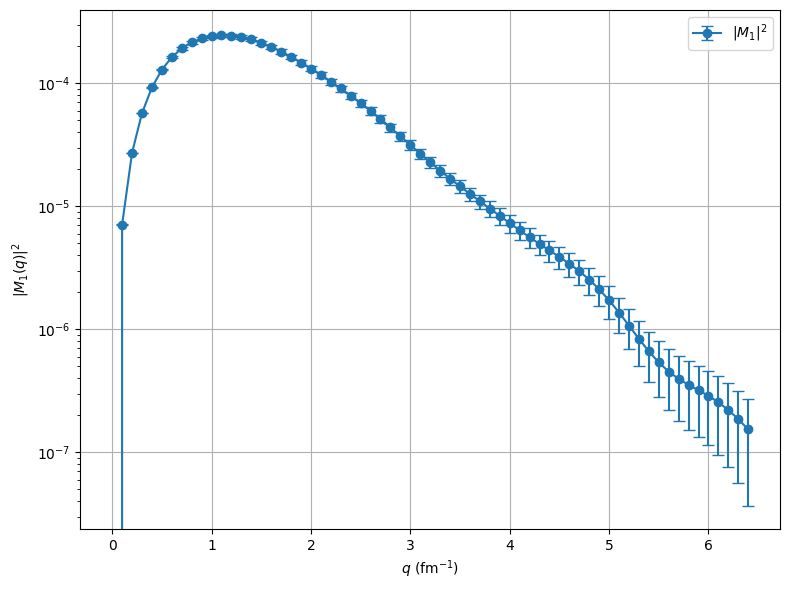

In [21]:
# Magnetic dipole multipole M1
prefactor_m1 = 1.0 / np.sqrt(np.pi)

# With J_new = J (lab frame) and hatqz: (ẑ × σ)_y = σ_x, so the
# spin-magnetic contribution sits in J[1] (J_y). Read index 1 here.
M_1      = prefactor_m1 * (mean_J_real[1, :q.size] + 1j * mean_J_imag[1, :q.size])
M_1_real_err = prefactor_m1 * variance_J_real[1, :q.size]
M_1_imag_err = prefactor_m1 * variance_J_imag[1, :q.size]

# Form factor |M_1|^2 and propagated error
M_1_sq     = M_1.real**2 + M_1.imag**2
M_1_sq_err = 2 * np.sqrt((M_1.real * M_1_real_err)**2 + (M_1.imag * M_1_imag_err)**2)

for i in range(q.size):
    print(f"q[{i}]: M_1 = {M_1.real[i]:.6e} + {M_1.imag[i]:.6e}i  |  |M_1|^2 = {M_1_sq[i]:.6e} +/- {M_1_sq_err[i]:.2e}")

plt.figure(figsize=(8, 6))
plt.errorbar(q, 1/3*M_1_sq, yerr=1/3*M_1_sq_err, fmt="o-", label=r"$|M_1|^2$", capsize=4)
plt.xlabel(r"$q$ (fm$^{-1}$)")
plt.ylabel(r"$|M_1(q)|^2$")
plt.yscale("log")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


q[0]: E_1 = 0.000000e+00 + 0.000000e+00i  |  |E_1|^2 = 0.000000e+00 +/- 0.00e+00
q[1]: E_1 = 8.439497e-22 + -1.481784e-04i  |  |E_1|^2 = 2.195683e-08 +/- 3.11e-11
q[2]: E_1 = 6.509587e-21 + -5.805141e-04i  |  |E_1|^2 = 3.369966e-07 +/- 7.46e-10
q[3]: E_1 = 2.059423e-20 + -1.262871e-03i  |  |E_1|^2 = 1.594844e-06 +/- 8.09e-09
q[4]: E_1 = 4.600401e-20 + -2.145775e-03i  |  |E_1|^2 = 4.604351e-06 +/- 4.09e-08
q[5]: E_1 = 8.425593e-20 + -3.173079e-03i  |  |E_1|^2 = 1.006843e-05 +/- 1.32e-07
q[6]: E_1 = 1.353106e-19 + -4.290159e-03i  |  |E_1|^2 = 1.840546e-05 +/- 3.16e-07
q[7]: E_1 = 2.071878e-19 + -5.449534e-03i  |  |E_1|^2 = 2.969742e-05 +/- 6.20e-07
q[8]: E_1 = 3.103134e-19 + -6.612989e-03i  |  |E_1|^2 = 4.373162e-05 +/- 1.05e-06
q[9]: E_1 = 4.334198e-19 + -7.750621e-03i  |  |E_1|^2 = 6.007213e-05 +/- 1.59e-06
q[10]: E_1 = 5.816365e-19 + -8.838243e-03i  |  |E_1|^2 = 7.811453e-05 +/- 2.23e-06
q[11]: E_1 = 7.326066e-19 + -9.854863e-03i  |  |E_1|^2 = 9.711833e-05 +/- 2.95e-06
q[12]: E_1 = 8.

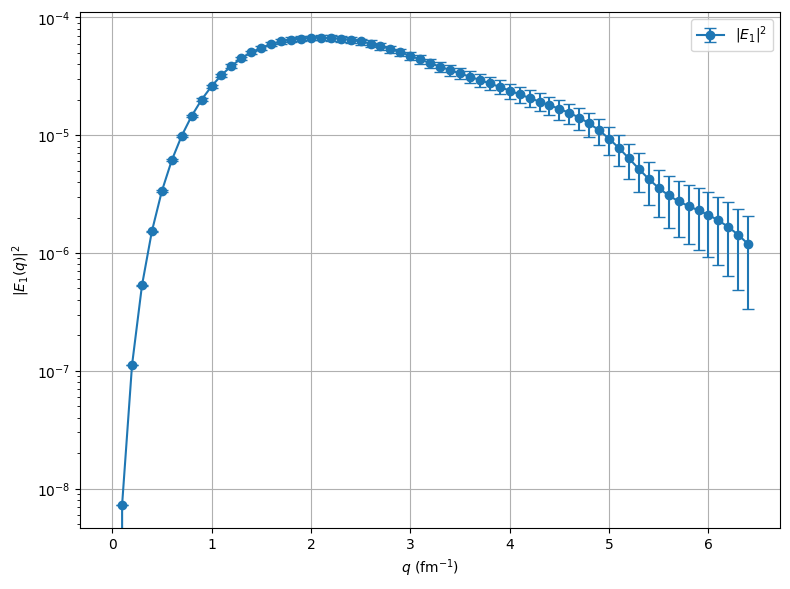

In [28]:
# Electric dipole multipole E1 (from EDM current, x component of rotated frame)
prefactor_e1 = 1.0 / np.sqrt(np.pi)

E_1          = prefactor_e1 * (mean_Jedm_real[0, :q.size] + 1j * mean_Jedm_imag[0, :q.size])
E_1_real_err = prefactor_e1 * variance_Jedm_real[0, :q.size]
E_1_imag_err = prefactor_e1 * variance_Jedm_imag[0, :q.size]

E_1_sq     = E_1.real**2 + E_1.imag**2
E_1_sq_err = 2 * np.sqrt((E_1.real * E_1_real_err)**2 + (E_1.imag * E_1_imag_err)**2)

for i in range(q.size):
    print(f"q[{i}]: E_1 = {E_1.real[i]:.6e} + {E_1.imag[i]:.6e}i  |  |E_1|^2 = {E_1_sq[i]:.6e} +/- {E_1_sq_err[i]:.2e}")

plt.figure(figsize=(8, 6))
plt.errorbar(q, 1/3*E_1_sq, yerr=1/3*E_1_sq_err, fmt="o-", label=r"$|E_1|^2$", capsize=4)
plt.xlabel(r"$q$ (fm$^{-1}$)")
plt.ylabel(r"$|E_1(q)|^2$")
plt.yscale("log")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


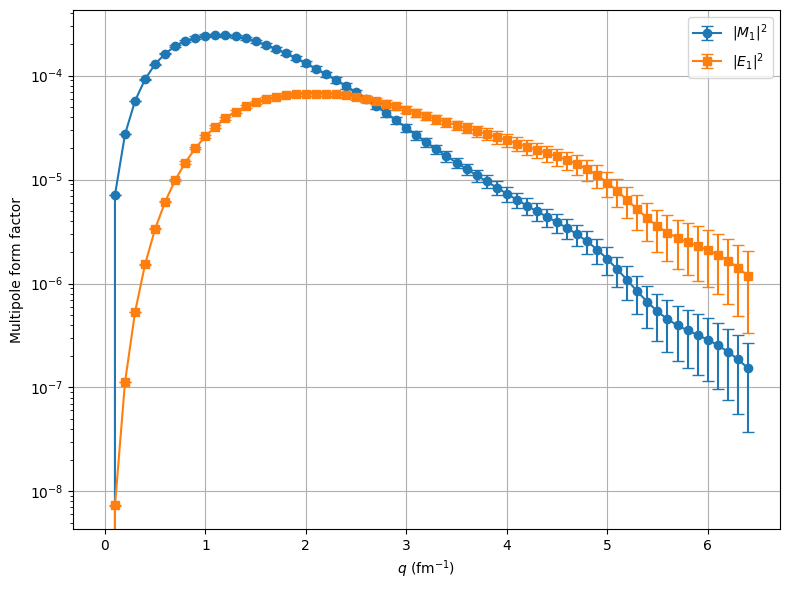

In [23]:
plt.figure(figsize=(8, 6))
plt.errorbar(q, 1/3*M_1_sq, yerr=1/3*M_1_sq_err, fmt="o-", label=r"$|M_1|^2$", capsize=4)
plt.errorbar(q, 1/3*E_1_sq, yerr=1/3*E_1_sq_err, fmt="s-", label=r"$|E_1|^2$", capsize=4)
plt.xlabel(r"$q$ (fm$^{-1}$)")
plt.ylabel(r"Multipole form factor")
plt.yscale("log")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


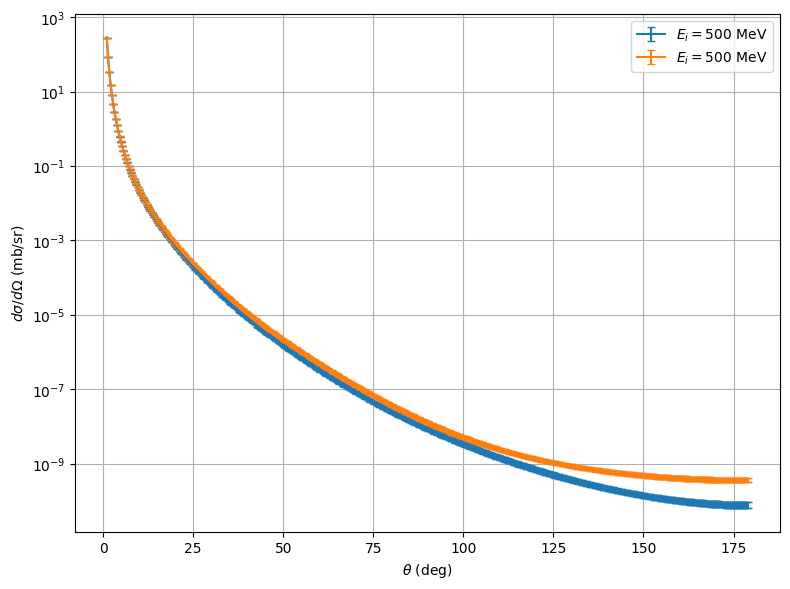

In [100]:
# L-T decomposition cross section vs scattering angle θ
# dσ/dΩ = σ_Mott × [(Q²/q²)² F_L² + (Q²/(2q²) + tan²(θ/2)) F_T²]

# Longitudinal and transverse form factors (J-averaged)
F_L_sq     = 1/3 * (C_0_sq + C_2_sq)
F_L_sq_err = 1/3 * np.sqrt(C_0_sq_err**2 + C_2_sq_err**2)
F_L_sq_edm     = 1/3 * (C_0_sq + C_1_sq + C_2_sq)
F_L_sq_err_edm = 1/3 * np.sqrt(C_0_sq_err**2 + C_1_sq_err**2 + C_2_sq_err**2)
F_T_sq_edm     = 1/3 * (M_1_sq + E_1_sq)
F_T_sq_err_edm = 1/3 * np.sqrt(M_1_sq_err**2 + E_1_sq_err**2)
F_T_sq     = 1/3 * (M_1_sq)
F_T_sq_err = 1/3 * np.sqrt(M_1_sq_err**2)
# Beam energy and angular grid
E_i       = 500.0                                      # MeV
M_d_MeV   = m_d * hbarc                               # deuteron mass in MeV
alpha     = 1.0 / 137.036

theta_deg = np.linspace(1.0, 179.0, 500)
theta     = np.radians(theta_deg)
sin2_half = np.sin(theta / 2)**2
tan2_half = np.tan(theta / 2)**2

# Elastic kinematics: deuteron recoil
E_f       = E_i * M_d_MeV / (M_d_MeV + 2 * E_i * sin2_half)  # MeV
omega_MeV = E_i - E_f                                           # MeV
Q2_MeV2   = 4 * E_i * E_f * sin2_half                          # MeV²
Q2_th     = Q2_MeV2 / hbarc**2                                  # fm⁻²
omega_fm  = omega_MeV / hbarc                                   # fm⁻¹
q_th      = np.sqrt(Q2_th + omega_fm**2)                        # fm⁻¹

# Interpolate precomputed form factors onto this q grid
F_L_sq_th     = np.interp(q_th, q, F_L_sq,     right=0.0)
F_L_sq_err_th = np.interp(q_th, q, F_L_sq_err, right=0.0)
F_T_sq_th     = np.interp(q_th, q, F_T_sq,     right=0.0)
F_T_sq_err_th = np.interp(q_th, q, F_T_sq_err, right=0.0)
F_T_sq_th_edm     = np.interp(q_th, q, F_T_sq_edm,     right=0.0)
F_T_sq_err_th_edm = np.interp(q_th, q, F_T_sq_err_edm, right=0.0)
F_L_sq_th_edm     = np.interp(q_th, q, F_L_sq_edm,     right=0.0)
F_L_sq_err_th_edm = np.interp(q_th, q, F_L_sq_err_edm, right=0.0)

# Kinematic factors
Q4_q4_th  = (Q2_th / q_th**2)**2
Q2_2q2_th =  Q2_th / (2 * q_th**2)

# Mott cross section (fm²/sr)
sigma_Mott_th = (alpha**2 * hbarc**2 * (1 - sin2_half)
                 / (4 * E_i**2 * sin2_half**2) * (E_f / E_i))

# Full cross section and error (converted fm²→mb: ×10)
sigma_th     = sigma_Mott_th * (Q4_q4_th * F_L_sq_th + (Q2_2q2_th + tan2_half) * F_T_sq_th)
sigma_err_th = sigma_Mott_th * np.sqrt((Q4_q4_th * F_L_sq_err_th)**2
                                       + ((Q2_2q2_th + tan2_half) * F_T_sq_err_th)**2)
sigma_th_edm     = sigma_Mott_th * (Q4_q4_th * F_L_sq_th_edm + (Q2_2q2_th + tan2_half) * F_T_sq_th_edm)
sigma_err_th_edm = sigma_Mott_th * np.sqrt((Q4_q4_th * F_L_sq_err_th_edm)**2
                                       + ((Q2_2q2_th + tan2_half) * F_T_sq_err_th_edm)**2)


plt.figure(figsize=(8, 6))
plt.errorbar(theta_deg, sigma_th * 10, yerr=sigma_err_th * 10,
             fmt='-', capsize=3, label=fr'$E_i = {E_i:.0f}$ MeV')
plt.errorbar(theta_deg, sigma_th_edm * 10, yerr=sigma_err_th_edm * 10,
             fmt='-', capsize=3, label=fr'$E_i = {E_i:.0f}$ MeV')
plt.xlabel(r'$\theta$ (deg)')
plt.ylabel(r'$d\sigma/d\Omega$ (mb/sr)')
plt.yscale('log')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
#Extra approach


